# Customer Churn Analysis - Predictive Modeling

## Stage Deliverables

* Defined architecture of ANN model.
* Trained ANN model on provided dataset.
* Predicted customer churn and evaluated model performance.

In this phase of the churn project we build and evaluate a single predictive model based on an Artificial Neural Network (ANN). Starting from loading the pre‑processed data, address any remaining duplicates or inconsistencies, drop the non‑informative customer_id column and separate Churn as the target variable. We then split the data into training and validation/test subsets and normalise the input features as needed. Next we define the architecture of a feed‑forward ANN. The network is compiled with a suitable loss function and optimiser and trained on the training data, with the validation set used to monitor performance and guard against overfitting. Finally, we predict customer churn on the held‑out test set and evaluate model performance using evaluation metrics along with a confusion matrix. Optional k‑fold cross‑validation can be applied to tune hyperparameters (e.g. number of neurons, learning rate) and confirm the robustness of the model. 

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import shutil
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve, f1_score
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.callbacks import EarlyStopping
from kerastuner import Objective
from kerastuner.tuners import Hyperband

import warnings
warnings.filterwarnings('ignore')

# Call models
from ANN_models import ANN_tf

C:\Users\ujfid\AppData\Local\Temp\ipykernel_33244\316247854.py:14: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import Objective


## 1. Data Loading and Preprocessing

In [2]:
# Read data from github
url = ("https://raw.githubusercontent.com/github7891/PY-DA-Team2/"
       "feature-engineer/data-preprocessing/data/processed/"
       "Dataset_ATS_v2_processed.csv")

preprocessed_df = pd.read_csv(url)
preprocessed_df.head()

,Unnamed: 0,customer_id,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,MonthlyCharges,Churn,gender_Female,gender_Male,InternetService_DSL,InternetService_Fiber optic,Contract_Month-to-month,Contract_One year,Contract_Two year
0,0,1,0,0,0.013889,0,0,0.069307,1,1,0,1,0,1,0,0
1,1,2,0,0,0.569444,1,0,0.069307,0,0,1,1,0,0,1,0
2,2,3,0,1,0.722222,1,0,0.009901,0,1,0,1,0,1,0,0
3,3,4,0,0,0.013889,1,0,0.574257,1,1,0,1,0,0,1,0
4,4,5,0,0,0.930556,1,0,0.326733,0,0,1,0,1,1,0,0


We drop `Unnamed: 0` and `customer_id` because they have no predictive value.

In [3]:
preprocessed_df.drop(columns = ['Unnamed: 0', 'customer_id'], axis = 1, inplace = True)

We correct the data inconsistency between phone service subscriptions and the number of lines by ensuring that customers who did not subscribe to any phone service cannot have multiple lines.

In [4]:
# Fix inconsistent MultipleLines values where PhoneService is 0
preprocessed_df.loc[(preprocessed_df['PhoneService'] == 0) & (preprocessed_df['MultipleLines'] != 0), 'MultipleLines'] = 0

From the cluster summary trained by the Elbow method, we can learn that the dataset wasn't entirely balanced. This could affect the metrics we will focus on in our tuning process.

$$
\text{Estimated churners} \approx (2202 \times 0.492) + (1733 \times 0.245) + (1948 \times 0.157) + (1160 \times 0.048)
\approx 1870 
$$

$$
\text{Total samples} = 7043
$$

In [5]:
# Churners(1) and non-churners(0) ratio
preprocessed_df['Churn'].value_counts(normalize=True)

0    0.73463
1    0.26537
Name: Churn, dtype: float64

We separate features (X) and target (Y) in our dataset, then use `train_test_split` function to divide them into 80% training and 20% testing.

In [6]:
# Separate features and targets
X = preprocessed_df.drop('Churn', axis=1)
y = preprocessed_df['Churn'].values

feature_names = X.columns.tolist()

# Split train test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

Unlike the earlier preprocessing stage where all data were scaled, we re-apply feature scaling specifically to the training and tests sets during modeling to prevent data leakage, and that scaling aligns with model training needs.

In [7]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

`X_train_scaled` and `X_test_scaled` are now numpy arrays of scaled feature values to be fed into our models. Stratification ensures the proportion of churners is the same in both sets.

## 2. Model Implementation Strategies in Churn Prediction

In this section, we implement and compare multiple modeling approaches to predict customer churn.

### 2.1 Scikit-Learn MLPClassifier Model

We train a Multi-Layer Perceptron (MLP) classifier using scikit-learn's `MLPClassifier` by defining a simple neural network with at least one hidden layer. Here we use one hidden layer of 64 neurons, ReLU activation, and the Adam optimizer.

In [8]:
# Initialise MLP
mlp = MLPClassifier(hidden_layer_sizes=(64, ), activation='relu',
                   solver='adam',
                   max_iter=200,
                   random_state=42)

# Fit the model
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(64,), random_state=42)

After training, we evaluate performance with accuracy, precicion, recall, and F1-score using scikit-learn's metrics.

In [9]:
# Predictions on test set and churner probability
y_pred = mlp.predict(X_test_scaled)
y_prob = mlp.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

              precision    recall  f1-score   support

           0       0.88      0.57      0.69      1035
           1       0.40      0.78      0.53       374

    accuracy                           0.63      1409
   macro avg       0.64      0.68      0.61      1409
weighted avg       0.75      0.63      0.65      1409

Confusion Matrix:
 [[591 444]
 [ 82 292]]


<h4 style="text-align: center;">Confusion Matrix</h4>
    
|                | Predicted No   | Predicted Yes   |
| -------------- | ---------------| ----------------|
| **Actual No**  | 591 (TN)       | 444 (FP)        |
| **Actual Yes** | 82 (FN)        | 292 (TP)        |


The confusion matrix showed that the model is good at catching churners, but makes a lot of false alarms, which might be ideal for retention strategies to catch more churners rather than identify the actual number of customers who churn.

### 2.1.1 Cross-Validation and Hyperparameter Tuning (MLPClassifier)

To ensure our model generalised well, we perform a 5-fold stratified cross-validation to compute average accuracy. 

In [10]:
# Average accuracy with cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

After that, we use `GridSearchCV` to find the best hyperparameters within the training data.

In [11]:
# Applying grid search
param_grid = {
    'hidden_layer_sizes': [(32,), (64,), (128,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'solver': ['adam', 'lbfgs'],
    'learning_rate': ['constant', 'adaptive']
}
grid = GridSearchCV(MLPClassifier(max_iter=200, random_state=42), 
                    param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)
print("Best Parameters:", grid.best_params_)

# Check overfitting
print("Best CV Accuracy:", round(grid.best_score_, 3))
print("Test Accuracy:", round(accuracy_score(y_test, grid.best_estimator_.predict(X_test_scaled)), 3))

Best Parameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (32,), 'learning_rate': 'constant', 'solver': 'adam'}
Best CV Accuracy: 0.788
Test Accuracy: 0.789


The best model has one hidden layer of 32 neurons each and a slightly higher regularisation (alpha 0.001) yielding a ~80% CV accuracy. Additionally, the cross-validation accuracy **78.8%** is consistent with the new test accuracy **78.9%**, indicating there is no major overfitting. Next, we apply the best parameters back to our MLP classifier and get our final report.

In [12]:
# Use the best parameters to create new MLP
best_params = grid.best_params_

best_mlp = MLPClassifier(
    hidden_layer_sizes=best_params.get('hidden_layer_sizes', (32,)),
    activation=best_params.get('activation', 'relu'),
    solver=best_params.get('solver', 'adam'),
    alpha=best_params.get('alpha', 0.001),
    learning_rate=best_params.get('learning_rate', 'constant'),
    max_iter=200,
    random_state=42
)

best_mlp.fit(X_train_scaled, y_train)

MLPClassifier(alpha=0.001, hidden_layer_sizes=(32,), random_state=42)

In [13]:
# Predictions on test set and churner probability
y_pred = best_mlp.predict(X_test_scaled)
y_prob = best_mlp.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix:
 [[934 101]
 [196 178]]


In [14]:
# Find best threshold for a more balanced performance
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1 = 2*(precision*recall)/(precision+recall+1e-6)
threshold = thresholds[f1.argmax()]

print(f"Best threshold: {threshold:.2f}")

Best threshold: 0.36


In [15]:
# Evaluation and confusion matrix
y_pred = (y_prob > threshold).astype(int)
y_prob = best_mlp.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1035
           1       0.55      0.64      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409

Confusion Matrix:
 [[842 193]
 [135 239]]


### 2.1.2 Model Comparison for Business Strategies

<h4 style="text-align: center;">Confusion Matrix</h4>

| Matrix | TN  | FP  | FN  | TP  | Business Goal    |
| ------ | --- | --- | --- | --- | ---------------- |
| **1**  | 934 | 101 | 196 | 178 | churn detection  |
| **2**  | 842 | 193 | 135 | 239 | churn prevention |

The first tuning result showed higher accuracy and precision, meaning that the model is better at catching churners, but also lose more potentional churners, optimal for detecting churners with a lower budget. The second result created more false alarms, however, saved more customers, even it might have to use more retention budget and flag a non-churner as a churner.

While scikit-learn provides a faster and more easily modified model, ANN models offer more flexibility to control over layers and advanced structures for more nonlinear layer captures.

### 2.2 Keras Artificial Neural Network (ANN) Model

Our first ANN model is the TensorFlow/Keras's Sequential API. We define a network with at least two hidden layers and batch normalisation for regularisation and training stability. We also include 2 dropouts for generalisation.

_**Notice that in the model, we also chose AUPRC metrics for future optimisation, in order to handle imbalanced data, minimise both false positives and false negatives.**_

### 2.2.1 Using Hyperband for Keras Model Tuning

In this section of tuning, we use `Hyperband` for our keras model, as it uses the least resource to train the top promising models. Once it reach its maximum performance, we insert a callback to stop training.

In [16]:
# Early stop for validation loss
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [17]:
# Initiate model class
ann = ANN_tf(input_dim=X_train_scaled.shape[1])

def hypermodel(hp): 
    return ann.model_keras(hp)

In [18]:
# Force directory refresh
shutil.rmtree('hyperband', ignore_errors=True) 

# Hyperband tuner and search
HBtuner = Hyperband(
    hypermodel,
    max_epochs=30,
    objective=Objective("val_auprc", direction="max"),
    executions_per_trial=3,
    directory='hyperband',
    project_name='krs_hyperband',
    overwrite=True)

HBtuner.search(X_train_scaled, y_train, validation_split=0.2, callbacks=[early_stop], verbose=1)

Trial 90 Complete [00h 00m 52s]
val_auprc: 0.6414668758710226

Best val_auprc So Far: 0.6622571349143982
Total elapsed time: 00h 32m 02s


### 2.2.2 Model Rebuild with Best Hyperparameters
Compare with the churner rate 0.26, a validation AUPRC with 0.66 shows that the model could correctly find more churners and not wrongly flagging loyal customers. After optimising auprc, we decided to filter out the trials with accuracies that didn't meet a specified threshold (<0.78) and keep the rest for model rebuild. Since we are no longer using keras tuner, we would have to replace the undefined hyperparameter (hp) with `units1`, `units2`, `lr` from our initial model, as well as the `hp.Int(...)` and `hp.Float(...)` from the layers.

In [19]:
# Get best params from hyperband
def get_best_params(tuner, keys=("units1", "units2", "units3", "lr")):
    all_trials = [t for t in tuner.oracle.get_best_trials() if t.status == "COMPLETED"]
    candidate = [t for t in all_trials
                 if t.metrics.get_last_value("val_accuracy") is not None
                 and t.metrics.get_last_value("val_accuracy") >= 0.78 
                 and t.metrics.get_last_value("val_auprc") is not None]
    if not candidate:
        hp = tuner.get_best_hyperparameters(num_trials=1)[0]
        return {k: hp.get(k) for k in keys}
    best = max(candidate, key=lambda t: t.metrics.get_last_value("val_auprc"))
    hp_vals = best.hyperparameters.values
    return {k: hp_vals[k] for k in keys}

In [21]:
# Call function to retrieve best parameters that also meet threshold
best_params = get_best_params(HBtuner)
print("Selected parameters: ", best_params)

# Retrian model
model = ann.model_rebuild(**best_params)
history = model.fit(X_train_scaled, y_train, 
                    validation_split=0.2, 
                    epochs=50, 
                    callbacks=[early_stop], 
                    verbose=0)

Selected parameters:  {'units1': 64, 'units2': 16, 'units3': 8, 'lr': 0.005974080448774755}


Now, we rebuild our model with cross validation to ensure the model reliably evaluate the best hp sets. We compute the weights of our imbalanced data to focus more on churners before we retrain them on a full dataset, then insert a scaler to guarantee that the scaled parameters are only learned from the train set.

In [24]:
# Set up 5 fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

val_auprcs = []
val_accuracies = []

for train_index, val_index in kf.split(X):
    X_train_cv,X_val_cv = X.iloc[train_index], X.iloc[val_index]
    y_train_cv,y_val_cv = y[train_index], y[val_index]
    
    # Calculate class weights
    weights = class_weight.compute_class_weight(
        class_weight='balanced', 
        classes=np.unique(y_train_cv), 
        y=y_train_cv)

    class_weights = dict(enumerate(weights))
    
    # Ensure train set and validation set are transformed to the same scale 
    scaler = StandardScaler()
    X_train_cv = scaler.fit_transform(X_train_cv)
    X_val_cv = scaler.transform(X_val_cv)
    
    # Refresh model for each iteration to save memory
    tf.keras.backend.clear_session()
    
    # Rebuild model with best hp
    model = ann.model_rebuild(**best_params)
    
    history = model.fit(X_train_cv, y_train_cv, 
                        validation_data=(X_val_cv, y_val_cv), 
                        epochs=50, 
                        batch_size=32, 
                        class_weight=class_weights, 
                        callbacks=[early_stop], 
                        verbose=0)
    
    # Evaluate validation
    _, auprc, acc = model.evaluate(X_val_cv, y_val_cv, verbose=0)
    val_auprcs.append(auprc)
    val_accuracies.append(acc)

In [25]:
# Get average results
print(f"Average AUPRC: {np.mean(val_auprcs):.4f} ± {np.std(val_auprcs):.2f}")
print(f"Average accuracy: {np.mean(val_accuracies):.4f} ± {np.std(val_accuracies):.2f}")

Average AUPRC: 0.5974 ± 0.05
Average accuracy: 0.7458 ± 0.01


The standard deviation indicates that the model is stable for both performance and consistency.

Finally, to see how the model perform on a full training set, we will now build and train a final model to conduct that.

In [43]:
# Scale and balance for the training set
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_scaled)
X_test_sc = scaler.transform(X_test)

weights = class_weight.compute_class_weight(
        class_weight='balanced', 
        classes=np.unique(y_train), 
        y=y_train)

class_weights = dict(enumerate(weights))

In [44]:
# Retrain and evaluate on full training set
final_model = ann.model_rebuild(**best_params)

history = final_model.fit(X_train_sc, y_train, 
                    validation_split=0.2, 
                    epochs=50, 
                    batch_size=32, 
                    class_weight=class_weights, 
                    callbacks=[early_stop], 
                    verbose=0)

# Get final result
_, test_auprc, test_accuracy = final_model.evaluate(X_test_sc, y_test, verbose=0)
print("\nFinal test set results")
print(f"Test AUPRC: {test_auprc:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


Final test set results
Test AUPRC: 0.5544
Test accuracy: 0.7516


The final results were not too different from the cross validation results, showing that the pipeline of our training is sound, from filtering, CV check, retrain, and finally the actual performance on a totally unseen data. The class weighting and scaling were both handled correctly without data leakage and overfitting, and that the mere performance drop was only due to some sample noise that are expected.

### 2.2.3 Visualisation and Insights

This section presents two visualisations to evaluate the model's performance. The confusion matrix shows how well the model distinguish churners from non-churners, and the permutation importance ranks features by their impact on predictive performance.

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


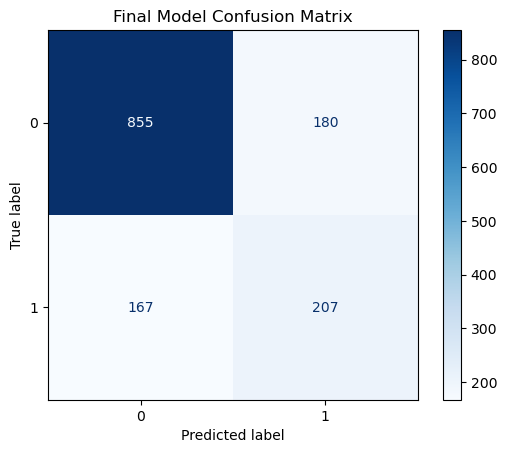

In [90]:
y_pred_probs = final_model.predict(X_test_sc)
y_pred = (y_pred_probs >= 0.4).astype(int)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues", values_format="d")
plt.title("Final Model Confusion Matrix")
plt.show()

The confusion matrix showed that the model correctly indentified most non-churners (855) and a fair number of churners (207). 

In [113]:
# Convert arrays
X_arr = np.asarray(X_test_sc)
y_arr = np.asarray(y_test)

# Baseline scores
base_scores = final_model.predict(X_arr, verbose=0).ravel()
base_auprc = average_precision_score(y_arr, base_scores)

drop = [] # How important the feature is
repeats = 6
rng = np.random.default_rng(42)

In [123]:
for i in range(X_arr.shape[1]):
    per_scores = []
    for _ in range(repeats):
        X_temp = X_arr.copy()
        rng.shuffle(X_temp[:, i]) # Shuffle one feature at a time
        score = final_model.predict(X_temp, verbose=0).ravel()
        per_scores.append(average_precision_score(y_arr, score))
    drop.append(base_auprc-np.mean(per_scores))
    
# Save to series
importance = pd.Series(drop, index=feature_names).sort_values(ascending=False)

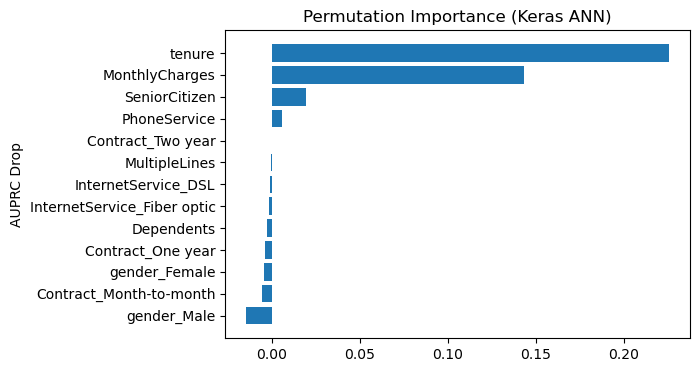

In [129]:
# Permutation plot
top_k = importance.head(15).iloc[::-1]
plt.figure(figsize=(6,4))
plt.barh(top_k.index, top_k.values)
plt.ylabel('AUPRC Drop')
plt.title("Permutation Importance (Keras ANN)")
plt.show()

The top features which are `tenure`, `MonthlyCharges`, and `SeniorCitizen` suggests that customers with short tenure or high bills, especially older customers, are more likely to leave.